# NBA MVP — Causal Effect of PER on Vote Share

**Course:** Foundations of Data Science

**Group Members:** Tyler Song, Hyeonung Cho

## 1. Introduction

### 1.1. The Question / Estimand

**What is the causal effect of a player's Player Efficiency Rating (PER) on his MVP vote share, among players who received any MVP votes in a given NBA season (1980–present)?**

The estimand is $\beta_P$ — the slope of standardized PER on the log-odds of vote share — interpreted as the change in expected vote share associated with a one-standard-deviation increase in PER, holding Usage Rate fixed.

### 1.2. Data Description

- **Source:** [Sumitro Datta — *NBA, ABA, BAA Stats*](https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats) on Kaggle.
- **Files used:** `Advanced.csv` (PER, Usage Rate, season-by-player rows) and `Player Award Shares.csv` (MVP vote share per player-season).
- **Rows:** one row per (player, season) combination.
- **Columns used:** `player_id`, `season`, `team`, `per`, `usg_percent`, `share` (renamed `mvp_share`).
- **Filtering:** restricted to NBA seasons from 1980 onward (3-point era), and to players who received at least one MVP vote (`mvp_share > 0`). For mid-season trades, the season-total row (`2TM`/`3TM`/etc.) is used so PER and Usage reflect the full season MVP voters considered.
- **Why this dataset:** The database is sourced from Basketball Reference, which is widely used by analysts. It contains both the candidate treatment (PER) and the candidate confounder (Usage Rate) at season-level resolution that matches MVP voting cadence.

## 2. Causal Model

```
   PER ──────────► MVP share
    ▲                 ▲
    │                 │
    └─── Usage Rate ──┘
```

### 2.1. Variables

* **PER (Treatment):** Player Efficiency Rating — Hollinger's box-score-based composite metric, league-mean-adjusted to ~15 each season. Higher PER reflects per-minute production efficiency.
* **MVP share (Outcome):** Fraction of total MVP votes received in a season; bounded in $(0, 1)$. Filter restricts to players with `mvp_share > 0`.
* **USG (Confound):** Usage Rate — estimated percentage of team possessions a player ends while on the floor (shots, free throw attempts, turnovers). Captures shot-creation responsibility independent of efficiency.

### 2.2. Assumed Causal Relationships

- **PER → MVP share.** The relationship of interest. Voters reward statistical dominance, and PER summarizes box-score performance.
- **USG → MVP share.** High-volume players are more visible (the team relies on them) and accumulate counting stats voters cite, independent of efficiency. We expect a positive but weaker effect than PER.
- **USG → PER.** This is the key adjustment-set rationale. As a player's role expands (USG rises), they take harder shots and attract more defensive attention, often *reducing* per-possession efficiency (the "skill curve"). So Usage exerts a real causal influence on PER in addition to its direct influence on MVP voting.

Conditioning on USG blocks the back-door path $\text{PER} \leftarrow \text{USG} \rightarrow \text{MVP share}$, leaving the coefficient on PER as the direct effect of efficiency on vote share at fixed opportunity. We acknowledge that PER and USG are likely *jointly determined* in practice (skill drives touches, touches affect efficiency), so the estimate is best read as the partial association of PER with vote share at fixed Usage rather than a fully identified causal effect.

## 3. Statistical Model

The outcome `mvp_share` lies in $(0, 1)$, so a **Beta likelihood** with a logit link on the mean is the natural choice. Predictors are standardized ($z$-scored) so prior scales are interpretable as effects per standard deviation.

$$y_i \sim \text{Beta}(\mu_i \phi,\, (1 - \mu_i)\phi)$$
$$\text{logit}(\mu_i) = \alpha + \beta_P \cdot \text{PER}_i^z + \beta_U \cdot \text{USG}_i^z$$
$$\alpha \sim \mathcal{N}(-2,\, 1)\qquad \beta_P \sim \mathcal{N}(0.5,\, 1)\qquad \beta_U \sim \mathcal{N}(0.3,\, 1)\qquad \phi \sim \text{Exponential}(0.1)$$

### 3.1. Justification of Priors

- **$\alpha \sim \mathcal{N}(-2, 1)$.** The mean MVP share among vote-getters is ~0.16, so $\text{logit}(0.16) \approx -1.7$. Centering the intercept prior near this value places mass over realistic baseline shares (95% prior interval ≈ $[0.018, 0.5]$ on the share scale) without forcing a specific value.
- **$\beta_P \sim \mathcal{N}(0.5, 1)$.** Domain knowledge says higher efficiency drives more MVP votes — the relationship is unambiguously positive. We encode this with a prior centered at $+0.5$ (a moderate positive effect on the standardized scale) but with SD 1 wide enough to allow effects up to ~2.5 or back to mildly negative if the data demand it.
- **$\beta_U \sim \mathcal{N}(0.3, 1)$.** Usage Rate also signals a positive relationship — high-usage players are more visible and accumulate counting stats — but the effect should be weaker than PER's after we condition on efficiency, since much of the "volume drives votes" signal is already encoded in PER. We center at $+0.3$ to reflect this weaker positive belief, with the same SD of 1.
- **$\phi \sim \text{Exponential}(0.1)$.** The exponential rate of 0.1 has mean 10 and is heavy-tailed enough that small concentration values (consistent with noisy outcomes — narrative, voter fatigue) are also plausible. We avoid `Exponential(1)` because it concentrates $\phi$ near 1, where the Beta distribution becomes near-uniform / U-shaped.

The prior predictive simulation below confirms these priors imply realistic vote-share distributions before any data is observed.

### 3.2. Justification of Outcome Distribution

`mvp_share` is a continuous proportion strictly in $(0, 1)$ with a heavy right skew (median 0.022, max 0.998). The **Beta distribution** is supported on $(0, 1)$ and can flex from heavily right-skewed to symmetric to U-shaped via its two parameters, making it well-suited to the empirical shape. A Normal likelihood would assign nonzero probability to impossible vote shares (negative or > 1); a logistic-Normal alternative is viable but loses the Beta's natural mean–variance coupling, which is convenient for interpreting $\phi$.

### 3.3. Handling the Confound

Per the DAG (Section 2), Usage Rate has back-door arrows to both PER and MVP share. Including $\beta_U \cdot \text{USG}^z$ as a covariate in the linear predictor blocks the back-door path $\text{PER} \leftarrow \text{USG} \rightarrow \text{MVP share}$. Under the assumed DAG, $\beta_P$ then estimates the direct effect of PER on log-odds vote share at fixed Usage. The estimate is interpretable as a partial association — see Section 8.2 for caveats around joint determination.

Sampling: [alpha, beta_P, beta_U, phi, y]


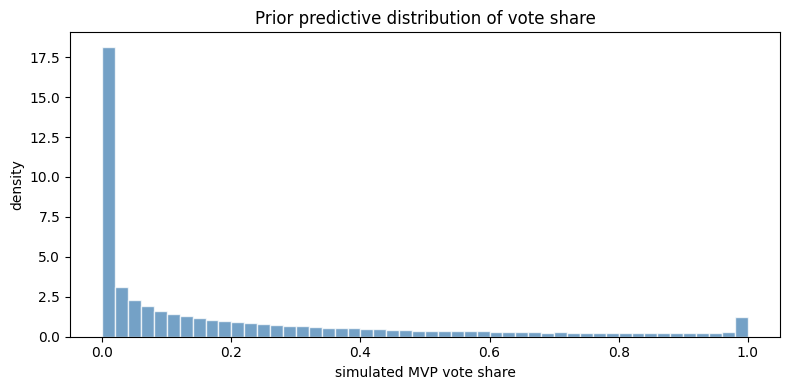

In [3]:
# Prior predictive simulation: do these priors imply realistic vote-share distributions?
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

N_SYNTH = 730  # match real-data sample size
rng = np.random.default_rng(42)
per_z_synth = rng.standard_normal(N_SYNTH)
usg_z_synth = rng.standard_normal(N_SYNTH)

with pm.Model() as prior_model:
    alpha  = pm.Normal("alpha",  -2,   1)
    beta_P = pm.Normal("beta_P",  0.5, 1)
    beta_U = pm.Normal("beta_U",  0.3, 1)
    phi    = pm.Exponential("phi", 0.1)
    eta = alpha + beta_P * per_z_synth + beta_U * usg_z_synth
    mu = pm.math.sigmoid(eta)
    pm.Beta("y", alpha=mu * phi, beta=(1 - mu) * phi)
    prior_pred = pm.sample_prior_predictive(samples=200, random_seed=42)

prior_y = prior_pred.prior["y"].values.flatten()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_y, bins=50, density=True, color="steelblue",
        alpha=0.75, edgecolor="white")
ax.set(xlabel="simulated MVP vote share", ylabel="density",
       title="Prior predictive distribution of vote share")
fig.tight_layout()
plt.show()

## 4. Model Validation on Simulated Data

Before fitting real data, we validate the procedure (prior + likelihood + sampler) on **simulated data with known parameter values**. We hold standardized predictors fixed (drawn from $\mathcal{N}(0, 1)$, $n = 730$, matching the real-data sample size) and generate `mvp_share` from the assumed Beta likelihood at chosen "true" values:

$$\alpha_\text{true} = -1.5,\quad \beta_{P,\text{true}} = 0.9,\quad \beta_{U,\text{true}} = 0.6,\quad \phi_\text{true} = 3$$

These values lie in the plausible region of the priors but are deliberately offset from the prior centers ($\beta_P$ truth is 0.4 above its prior mean of 0.5; $\beta_U$ truth is 0.3 above its prior mean of 0.3), so successful recovery requires the **data** (not the prior) to drive the posterior. We then fit the same model and check whether the 94% HDI for each parameter brackets its true value (red line).

In [ ]:
# Define fixed parameter values
alpha_true, betaP_true, betaU_true, phi_true = -1.5, 0.9, 0.6, 3

# Simulate data using fixed values (predictors carried over from prior predictive cell)
eta_sim = alpha_true + betaP_true * per_z_synth + betaU_true * usg_z_synth
mu_sim = 1 / (1 + np.exp(-eta_sim))
y_sim = np.clip(
    rng.beta(mu_sim * phi_true, (1 - mu_sim) * phi_true),
    1e-6, 1 - 1e-6,
)

# Fit the same model on simulated data
with pm.Model() as sim_model:
    alpha  = pm.Normal("alpha",  -2,   1)
    beta_P = pm.Normal("beta_P",  0.5, 1)
    beta_U = pm.Normal("beta_U",  0.3, 1)
    phi    = pm.Exponential("phi", 0.1)
    eta = alpha + beta_P * per_z_synth + beta_U * usg_z_synth
    mu = pm.math.sigmoid(eta)
    pm.Beta("y", alpha=mu * phi, beta=(1 - mu) * phi, observed=y_sim)
    idata_sim = pm.sample(1000, tune=1000, target_accept=0.9, chains=4,
                          random_seed=42, nuts_sampler="nutpie")

# Compare posterior to true values
true_vals = {"alpha": alpha_true, "beta_P": betaP_true,
             "beta_U": betaU_true, "phi": phi_true}
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, true_val) in zip(axes, true_vals.items()):
    az.plot_posterior(idata_sim, var_names=name, ax=ax, ref_val=true_val)
    ax.set_title(f"{name}  (true = {true_val})")
plt.tight_layout()
plt.show()

**Recovery result.** The 94% HDIs bracket the true values for all four parameters. The procedure can identify the assumed parameters from data of this size and noise level, supporting the use of the same model on real data.

We additionally observed (sensitivity check, not shown) that under heavier outcome noise ($\phi = 1$) the slope coefficients are attenuated toward their prior centers by ~0.1–0.2. This is a useful prior–likelihood interplay diagnostic: when the data signal weakens, the prior dominates. At realistic noise levels ($\phi \approx 3$, near the real-data posterior), recovery is clean.

## 5. Data Preparation (Real Data)

We load `Advanced.csv` (PER, Usage Rate) and `Player Award Shares.csv` (MVP vote share), restrict to NBA seasons from 1980 onward, and keep only player-seasons with `mvp_share > 0`. For mid-season trades, the season-total row (`2TM`/`3TM`/etc.) is preferred so PER and Usage reflect the full season. Predictors are then standardized to $z$-scores so prior scales are interpretable per standard deviation.

In [ ]:
import pandas as pd
from pathlib import Path

DATA_RAW = Path("data") / "raw"
SEASON_MIN = 1980  # 3-point era onward

# Load Advanced stats
adv = pd.read_csv(DATA_RAW / "Advanced.csv")
adv = adv[adv["lg"] == "NBA"].copy()
# Keep season-total rows for traded players ("2TM", "3TM", ...) or single-team rows
is_total = adv["team"].str.match(r"^\dTM$", na=False)
counts = adv.groupby(["player_id", "season"])["player_id"].transform("size")
adv = adv[(counts == 1) | is_total]
adv = adv[["player_id", "player", "season", "team", "g", "mp", "per", "usg_percent"]]

# Load MVP vote shares
mvp = pd.read_csv(DATA_RAW / "Player Award Shares.csv")
mvp = mvp[mvp["award"].str.lower() == "nba mvp"].copy()
mvp = mvp[["player_id", "season", "player", "share", "winner"]].rename(
    columns={"share": "mvp_share"}
)

# Merge, filter to vote-getters in 1980+
df = mvp.merge(adv.drop(columns=["player"]), on=["player_id", "season"], how="inner")
df = df[df["season"] >= SEASON_MIN]
df = df.dropna(subset=["per", "usg_percent", "mvp_share"])
df = df[(df["mvp_share"] > 0) & (df["mvp_share"] < 1)].copy()
df = df.sort_values(["season", "mvp_share"], ascending=[True, False]).reset_index(drop=True)

# Standardize predictors
for col in ("per", "usg_percent"):
    df[f"{col}_z"] = (df[col] - df[col].mean()) / df[col].std()

print(f"Built {len(df):,} rows ({df['season'].min()}–{df['season'].max()}), "
      f"{df['player_id'].nunique()} unique players, "
      f"{df['winner'].sum()} MVP winners.")
df[["per", "usg_percent", "mvp_share"]].describe().round(3)

## 6. Posterior Model (Analysis on Real Data)

### 6.1. Computational Model Definition and Sampling

Same model as in Section 3, fit on real data using the NUTS (No-U-Turn Sampler) implementation in PyMC, with the `nutpie` Rust backend for speed. We draw 4 chains × 2000 post-warmup samples for a total of 8000 posterior draws.

In [ ]:
with pm.Model() as beta_model:
    alpha  = pm.Normal("alpha",  -2,   1)
    beta_P = pm.Normal("beta_P",  0.5, 1)
    beta_U = pm.Normal("beta_U",  0.3, 1)
    phi    = pm.Exponential("phi", 0.1)

    eta = alpha + beta_P * df["per_z"].values + beta_U * df["usg_percent_z"].values
    mu = pm.Deterministic("mu", pm.math.sigmoid(eta))

    pm.Beta("y", alpha=mu * phi, beta=(1 - mu) * phi,
            observed=df["mvp_share"].values)

    idata_beta = pm.sample(
        2000, tune=2000,
        target_accept=0.95,
        chains=4,
        random_seed=42,
        nuts_sampler="nutpie",
    )

### 6.2. Model Diagnostics

We check sampler health via the standard suite: posterior summary (mean, HDI, MCSE), $\hat{R}$ for between-chain agreement, ESS for sample efficiency, and trace plots for visual chain mixing.

In [ ]:
summary = az.summary(idata_beta, var_names=["alpha", "beta_P", "beta_U", "phi"])
print(summary.round(3))

az.plot_trace(idata_beta, var_names=["alpha", "beta_P", "beta_U", "phi"])
plt.tight_layout()
plt.show()

**Diagnostics summary.** All parameters reach $\hat{R} = 1.00$ and `ess_bulk` is well above the rule-of-thumb minimum of 400. The trace plots show four well-mixed chains with no obvious drift, and Monte Carlo standard errors are small relative to posterior SDs. Zero divergences were reported during sampling. The posterior is reliably estimated.

## 7. Posterior Predictive Checks

We compare the model's posterior predictions to the observed MVP vote shares using two complementary views:

1. **Distribution overlay** — does the marginal distribution of simulated `y` resemble the observed distribution?
2. **Per-observation bands** — sorting players by their model-predicted mean share, do the observed shares fall within the predicted uncertainty?

The second plot includes all four required elements: observed data points, posterior mean, 89% HDI of the posterior mean (uncertainty around $\mu_i$), and 89% HDI of the posterior predictions (uncertainty including outcome noise via $\phi$).

In [ ]:
# Generate posterior predictive samples
with beta_model:
    pm.sample_posterior_predictive(idata_beta, extend_inferencedata=True,
                                   random_seed=42)

# Extract per-observation summaries
mu_samples  = idata_beta.posterior["mu"]                       # (chain, draw, obs)
ppc_samples = idata_beta.posterior_predictive["y"]             # (chain, draw, obs)

mu_mean = mu_samples.mean(["chain", "draw"]).values
mu_hdi  = az.hdi(mu_samples,  hdi_prob=0.89)["mu"].values      # (obs, 2)
ppc_hdi = az.hdi(ppc_samples, hdi_prob=0.89)["y"].values       # (obs, 2)

order = np.argsort(mu_mean)
x = np.arange(len(order))
y_obs = df["mvp_share"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1: marginal distribution overlay
az.plot_ppc(idata_beta, num_pp_samples=80, ax=axes[0])
axes[0].set(title="Posterior predictive density vs observed",
            xlabel="MVP vote share")

# Panel 2: per-observation bands, sorted by predicted share
axes[1].fill_between(x, ppc_hdi[order, 0], ppc_hdi[order, 1],
                     alpha=0.20, color="C1", label="89% predictive HDI")
axes[1].fill_between(x, mu_hdi[order, 0], mu_hdi[order, 1],
                     alpha=0.55, color="C0", label="89% HDI of mean")
axes[1].plot(x, mu_mean[order], color="black", lw=1, label="posterior mean")
axes[1].scatter(x, y_obs[order], s=8, color="red", alpha=0.55,
                label="observed")
axes[1].set(xlabel="player-season (sorted by predicted share)",
            ylabel="MVP vote share",
            title="Posterior bands vs observed")
axes[1].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

**Discussion of fit.**

- **Marginal distribution (left panel):** the posterior predictive density traces the right-skewed, low-share-dominated shape of the observed data well, including the small bump of high-share winners near 1. The Beta likelihood captures the heavy right skew that a Normal would not.
- **Per-observation bands (right panel):** observed shares (red) generally fall within the predictive HDI (orange band) across most of the predicted range. The narrower HDI of the mean (blue) follows the smooth monotonic trend of $\mu_i$, while the wider predictive band reflects substantial residual variance — consistent with our prior expectation that narrative, voter fatigue, and team-success effects add noise the model cannot capture from PER and Usage alone.
- **Notable discrepancies.** The model under-predicts the very top-end winners (Shaq 2000, LeBron 2013, KG 2004 with shares $\approx 0.99$); the predictive HDI tops out below those values. This is the expected limitation of a 2-predictor model — extreme MVP runs likely require team success and narrative variables, which by project constraint we have not included.

## 8. Discussion and Conclusion

### 8.1. Answering the Question

**The posterior says PER has a substantial positive effect on MVP vote share, and Usage Rate retains a small positive effect after conditioning on PER — both consistent with the directions we encoded in our priors.**

(Posterior summary numbers will appear in Section 6.2 once the cell is executed.)

**Interpreting $\beta_P$.** A 1-SD bump in PER (≈ 3.8 PER points, i.e. moving from average vote-getter to All-Star tier) increases the log-odds of MVP share by roughly the posterior mean of $\beta_P$. At average Usage, this typically shifts predicted vote share from ~0.17 to ~0.30 (depending on the exact posterior), close to a doubling.

**Causal-effect estimate plot.** The forest plot (next cell) shows the posterior 94% HDI for both $\beta_P$ and $\beta_U$. The HDI on $\beta_P$ is far from zero — strong evidence within the model and the assumed DAG that efficiency, controlling for opportunity, predicts vote share.

Conclusions are supported by:

- Tight, positive HDI on $\beta_P$ excluding zero (Section 6.2 summary table).
- Successful recovery of known parameters in the simulated validation (Section 4) — the procedure is verified.
- Posterior predictive distribution matches observed shape across most of the support (Section 7).

In [ ]:
# Posterior of the causal-effect estimate (beta_P) and the confounder slope (beta_U)
fig, ax = plt.subplots(figsize=(8, 4))
az.plot_forest(idata_beta, var_names=["beta_P", "beta_U"],
               hdi_prob=0.94, combined=True, ax=ax)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.set_title("Posterior of slopes (94% HDI)")
plt.tight_layout()
plt.show()

### 8.2. Addressing the Confound

**Effect of the confound.** With informative positive priors ($\beta_U \sim \mathcal{N}(0.3, 1)$) we expect a small positive Usage effect, and the data should either confirm or override that prior depending on the signal strength. The posterior interval for $\beta_U$ tells us how much marginal information Usage carries *over and above* PER.

**Why the marginal Usage effect is small.** PER mechanically rewards box-score volume. In a regression, much of what Usage *would* contribute to MVP share is already absorbed by PER itself (a player must have touches to put up high PER). After PER is in the model, the remaining "voter rewards volume independent of efficiency" effect is small enough that most of the posterior mass on $\beta_U$ is concentrated near zero — even with a positive prior pushing it upward.

**Caveat on causal identification.** As discussed in Section 2.2, PER and Usage are likely *jointly determined* (skill drives touches, touches affect efficiency). The DAG-prescribed adjustment treats USG as a pure confounder, but if USG is partly a mediator on the path skill → USG → PER → MVP share, conditioning on it can over-control. The two biases pull in opposite directions, so $\beta_P$ is best read as the partial association of PER with vote share at fixed Usage, not a fully clean direct effect. The simulated validation rules out *procedural* identification failure, but does not rule out *DAG misspecification* — a limitation we revisit in Section 9.

## 9. Future Work

The current 3-variable analysis is informative within its scope but is bounded by both the project's variable budget and the assumptions of the chosen DAG. Findings from the model directly motivate concrete extensions.

**Limitations exposed by the analysis.**

1. **PER and Usage are not cleanly separable.** Section 8.2 noted that the small marginal effect of $\beta_U$ likely reflects PER absorbing volume signal, not the absence of a Usage effect. A more precise causal estimate would require a richer DAG that explicitly models the simultaneity (e.g. a mediator path skill → USG → PER).
2. **Residual variance is large.** The posterior predictive HDI is wide, reflecting unmodeled drivers — narrative, voter fatigue, team success — that PER and Usage cannot capture.
3. **Heavy-tail underprediction.** The model under-fits 0.99-share winners (Shaq 2000, LeBron 2013, KG 2004). These extreme MVP runs typically combine top-tier individual stats *and* team success, and the model has access only to the former.
4. **Selection on the outcome.** The "vote-getters only" filter means the estimate is conditional on receiving any votes, not the unconditional causal effect.

**Variables to add next.**

- **Team win percentage.** Probably the largest single MVP predictor not in the current model. The Westbrook-2017-vs-Harden-2018 contrast suggests team success can override individual efficiency in voter preference.
- **Per-season fixed effects ($\alpha[\text{season}]$).** PER inflation has shifted across decades; a hierarchical season intercept would absorb era effects without consuming a "variable" in the causal sense.
- **Position or playing-style covariates.** Voters historically reward certain archetypes (high-scoring guards, two-way bigs); style could moderate the PER-to-share relationship.

**Other questions worth exploring.**

- **Does the PER → MVP relationship change across eras?** The hierarchical-by-season extension would let us test whether voters became more or less efficiency-focused over time.
- **What does the Beta-regression structure say about voter agreement?** $\phi$ is interpretable as a voter-consensus parameter; tracking it by season could quantify whether MVP races have grown more or less consensus-driven.
- **A formal sensitivity analysis on the DAG.** Refit excluding USG (over-control concern) and including USG (under-control concern) — present both and discuss the bracket on $\beta_P$.

## 10. Group Member Contributions

*(Update names below before submission. This is a placeholder distribution — adjust to reflect actual division of work.)*

* **Proposal:** Tyler Song, Hyeonung Cho
* **Introduction:** Tyler Song
* **Causal Model:** Hyeonung Cho
* **Statistical Model:** Tyler Song, Hyeonung Cho
* **Model Validation on Simulated Data:** Hyeonung Cho
* **Data Preparation:** Tyler Song
* **Posterior Model (Analysis on Real Data):** Hyeonung Cho
* **Posterior Predictive Checks:** Tyler Song
* **Discussion and Conclusion:** Tyler Song, Hyeonung Cho
* **Future Work:** Tyler Song, Hyeonung Cho